In [127]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from helper_function import plot_decision_boundary, accuracy_fn
from sklearn.decomposition import PCA

In [128]:
X, y = load_breast_cancer(return_X_y = True)
pca = PCA(n_components = 2)
X = pca.fit_transform(X)

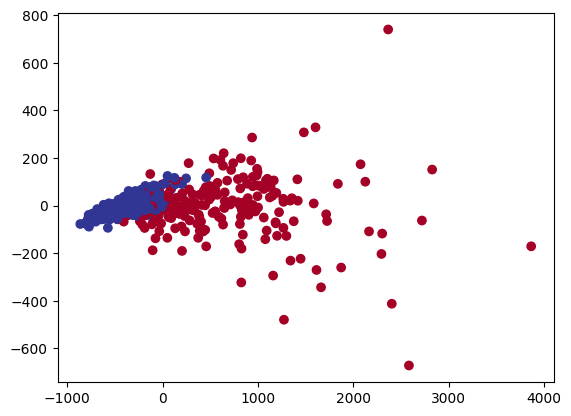

In [129]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [130]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [131]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [133]:
X_train.shape, y_train.unique()

(torch.Size([455, 2]), tensor([0., 1.]))

In [134]:
class BreastCancerClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_features = 2, out_features = 64),
            nn.ReLU(),
            nn.Linear(in_features = 64, out_features = 64),
            nn.ReLU(),
            nn.Linear(in_features = 64, out_features = 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [135]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [136]:
model = BreastCancerClassification().to(device)
model

BreastCancerClassification(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [137]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [138]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [139]:
epochs = 10000
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train).squeeze()
    train_accuracy = accuracy_fn(y_train, y_pred)

    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test).squeeze()
        test_accuracy = accuracy_fn(y_test, y_test_pred)

        test_loss = loss_fn(y_test_pred, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 31.02277374267578 | Test Loss: 2.2061264514923096
Train Accuracy: 0.21978021978021978 | Test Accuracy: 85.96491228070175

Train Loss: 5.826125144958496 | Test Loss: 5.2802839279174805
Train Accuracy: 84.83516483516483 | Test Accuracy: 91.22807017543859

Train Loss: 5.944788455963135 | Test Loss: 5.278218746185303
Train Accuracy: 88.79120879120879 | Test Accuracy: 92.10526315789474

Train Loss: 5.943397045135498 | Test Loss: 5.285605430603027
Train Accuracy: 89.8901098901099 | Test Accuracy: 92.10526315789474

Train Loss: 5.943341255187988 | Test Loss: 5.275191307067871
Train Accuracy: 90.32967032967034 | Test Accuracy: 92.10526315789474

Train Loss: 5.943212032318115 | Test Loss: 5.272196292877197
Train Accuracy: 90.10989010989012 | Test Accuracy: 92.10526315789474

Train Loss: 5.943226337432861 | Test Loss: 5.274174213409424
Train Accuracy: 90.10989010989012 | Test Accuracy: 92.10526315789474

Train Loss: 5.943197250366211 | Test Loss: 5.271263122558594
Train Accuracy: 90.

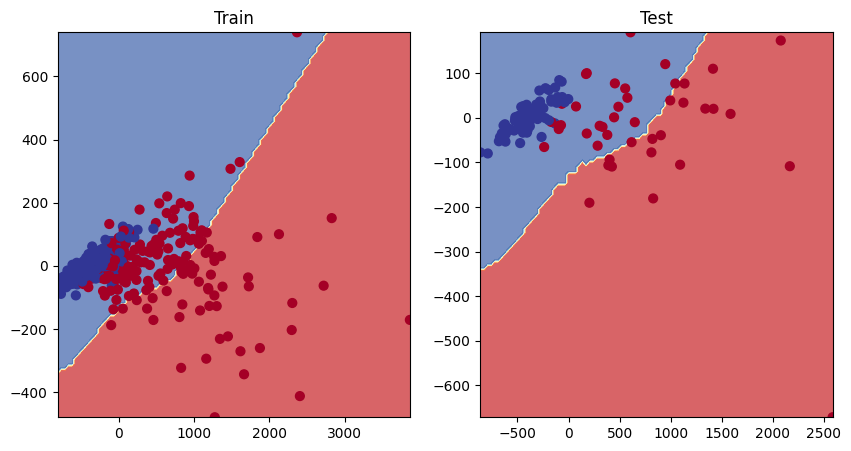

In [67]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test.cpu(), y_test.cpu())